In [3]:
import pandas as pd 
import requests
import time
import os
import numpy as np
import py3Dmol
from Bio.PDB import PDBParser
from Bio.PDB.SASA import ShrakeRupley
import matplotlib.pyplot as plt




In [4]:
'''
Data Loading and Preprocessing 

1: Load the Dataset. Split the dataset based on the type of disease. 
2: Split the dataset into 
2: Create the split for training and testing data. From the looks of the split 


'''

'\nData Loading and Preprocessing \n\n1: Load the Dataset. Split the dataset based on the type of disease. \n2: Split the dataset into \n2: Create the split for training and testing data. From the looks of the split \n\n\n'

In [12]:
df = pd.read_csv('/Users/shubhaychoubey/Documents/GitHub/Peptide/NewDatasetWithValues.csv')

# Split the dataset based on MHC. 

mhc_groups = df.groupby('MHC Class')

folder_name = '/Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/final_data'

# Save a new CSV for each MHC class
for mhc_class, group in mhc_groups:
    filename = f'{folder_name}/{mhc_class}_dataset.csv'
    group.to_csv(filename, index=False)

# Save data to this file: Notebooks/Data/final_data.cs


In [14]:
df_1 = pd.read_csv('/Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/final_data/I_dataset.csv')
df_2 = pd.read_csv('/Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/final_data/II_dataset.csv')

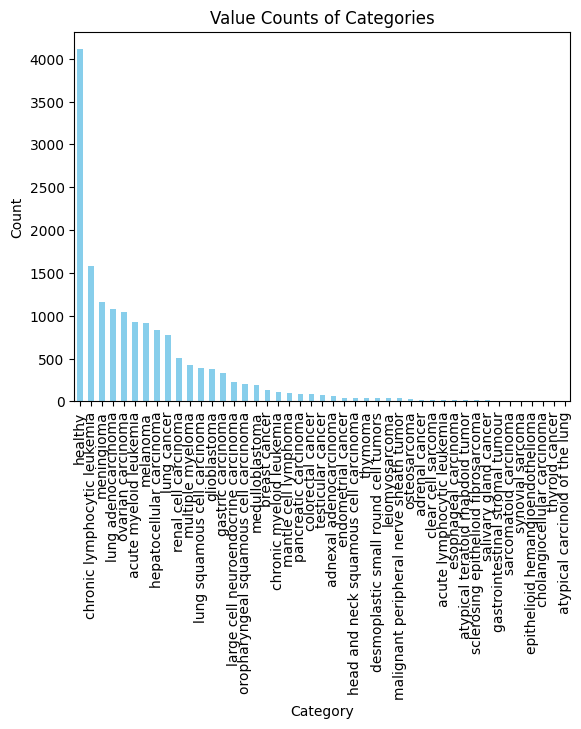

Disease
healthy                                    4108
chronic lymphocytic leukemia               1578
meningioma                                 1163
lung adenocarcinoma                        1077
ovarian carcinoma                          1044
acute myeloid leukemia                      928
melanoma                                    917
hepatocellular carcinoma                    832
lung cancer                                 770
renal cell carcinoma                        513
multiple myeloma                            422
lung squamous cell carcinoma                392
glioblastoma                                384
gastric carcinoma                           328
large cell neuroendocrine carcinoma         226
oropharyngeal squamous cell carcinoma       202
medulloblastoma                             190
breast cancer                               136
chronic myeloid leukemia                    106
mantle cell lymphoma                        103
pancreatic carcinoma            

In [ ]:
# Data Imbalance for MHC 1. 

tissue_counts = df_1['Disease'].value_counts()
tissue_counts.plot(kind='bar', color='skyblue')
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Value Counts of Categories')
plt.show()

print(tissue_counts)

number_of_healthy = sum(df_1['Disease'] == 'healthy')
number_of_nonhealthy = sum(df_1['Disease'] != 'healthy')

print(f"Number of Healthy samples: {number_of_healthy}")
print(f"Number of Non-Healthy samples: {number_of_nonhealthy}")
print(f"Total samples: {len(df_1)}, Imbalanece Ratio: {number_of_healthy/number_of_nonhealthy:.2f}")

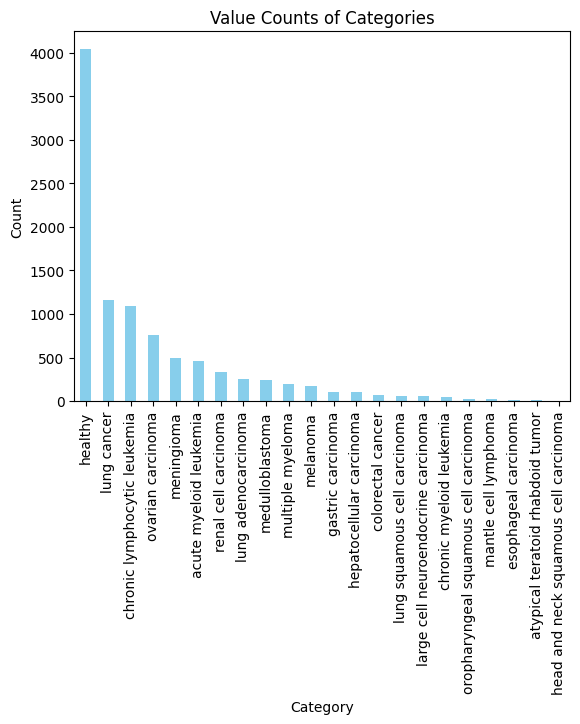

Disease
healthy                                  4042
lung cancer                              1161
chronic lymphocytic leukemia             1093
ovarian carcinoma                         758
meningioma                                494
acute myeloid leukemia                    466
renal cell carcinoma                      339
lung adenocarcinoma                       256
medulloblastoma                           241
multiple myeloma                          201
melanoma                                  168
gastric carcinoma                         110
hepatocellular carcinoma                   99
colorectal cancer                          72
lung squamous cell carcinoma               64
large cell neuroendocrine carcinoma        61
chronic myeloid leukemia                   43
oropharyngeal squamous cell carcinoma      28
mantle cell lymphoma                       22
esophageal carcinoma                       16
atypical teratoid rhabdoid tumor           14
head and neck squamous cel

In [27]:
# Data Imbalance for MHC 2.

tissue_counts = df_2['Disease'].value_counts()
tissue_counts.plot(kind='bar', color='skyblue')
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Value Counts of Categories')
plt.show()

print(tissue_counts)

number_of_healthy = sum(df_2['Disease'] == 'healthy')
number_of_nonhealthy = sum(df_2['Disease'] != 'healthy')

print(f"Number of Healthy samples: {number_of_healthy}")
print(f"Number of Non-Healthy samples: {number_of_nonhealthy}")
print(f"Total samples: {len(df_2)}, Imbalanece Ratio: {number_of_healthy/number_of_nonhealthy:.2f}")


In [30]:
#length of peptides in data. 

df_1['Peptide Length'] = df_1['Peptide Sequence'].apply(len)
df_2['Peptide Length'] = df_2['Peptide Sequence'].apply(len)

avg_length_mhc1 = df_1['Peptide Length'].mean()
avg_length_mhc2 = df_2['Peptide Length'].mean()

print(f"Average Peptide Length for MHC Class I: {avg_length_mhc1:.2f}")
print(f"Average Peptide Length for MHC Class II: {avg_length_mhc2:.2f}")

print(range(df_1['Peptide Length'].min(), df_1['Peptide Length'].max() + 1))
print(range(df_2['Peptide Length'].min(), df_2['Peptide Length'].max() + 1))

Average Peptide Length for MHC Class I: 9.43
Average Peptide Length for MHC Class II: 15.83
range(8, 16)
range(8, 31)


In [ ]:
# Augmenting the data for class 1 and class 2 MHC to ensure we can have 1) more healthy types to fix inmabalence, 
# 2) more data to train the model on for both classes. 
#3 ) So we can add in more biological features to the data.
#4) Data will be grabbed from IEPD and CEDAR databases. Should be almost 25,000 samples for each class.
